### create map from fit parameters


In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/2026_maps_experiment/final_maps'


In [2]:
directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23'
directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_22'
directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_17'
directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_15_thp1'
directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_13'
directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2025_11_06'
directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_11_04_test'

#test map
# directory_maps = '/Volumes/SSK_Drive/golden_map/psnex_map___2025.03.12_18.38.42.45'

directory_maps = '/Volumes/SSK_Drive/2026_map_ctc44_3d/'

In [3]:

map_paths = maps.find_psnex_map_folders(directory_maps)
print(f"Found {len(map_paths)} map folders in {directory_maps}")

if len(map_paths) == 0:
    map_paths = [directory_maps]


Found 86 map folders in /Volumes/SSK_Drive/2026_map_ctc44_3d/


In [4]:
maps_to_analyze = ['psnex_map___2026.04.23_18.23.29.37',
                   'psnex_map___2026.04.23_17.11.50.57_log',
                   'psnex_map___2026.04.23_15.39.46.49_log',
                   'psnex_map___2026.04.15_14.45.59.91_log',
                   'psnex_map___2026.04.17_14.20.47.21_log',
                   'psnex_map___2026.04.22_17.19.25.60',


]

# match the names of the maps_to_analyze with the map_paths.
# If map_paths contain any match from maps_to_analyze, then add to list of maps to analyze paths.
maps_to_analyze_paths = []
for map_path in map_paths:
    map_name = os.path.basename(map_path)
    if any(map_name in map_to_analyze for map_to_analyze in maps_to_analyze):
        maps_to_analyze_paths.append(map_path)  
print(f"Found {len(maps_to_analyze_paths)}/{len(maps_to_analyze)} maps to analyze in {directory_maps}")




Found 6/6 maps to analyze in /Volumes/SSK_Drive/2026_map_ctc44_3d/


processing file : /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_22/sample_2/psnex_map___2026.04.22_17.19.25.60
segment duration 23.83182, 
 numb of point cal (ticks, dec, sampling rate 148948, num pts stored per segment 148948
segment duration 3.45044, 
 numb of point cal (ticks, dec, sampling rate 21565, num pts stored per segment 21563
df_point log made
segment duration 18.234593999999998, 
 numb of point cal (ticks, dec, sampling rate 113966, num pts stored per segment 113965
segment duration 3.564802, 
 numb of point cal (ticks, dec, sampling rate 22280, num pts stored per segment 22278
df_point log made
segment duration 20.68012, 
 numb of point cal (ticks, dec, sampling rate 129250, num pts stored per segment 129250
segment duration 3.781614, 
 numb of point cal (ticks, dec, sampling rate 23635, num pts stored per segment 23633
df_point log made
segment duration 20.21622, 
 numb of point cal (ticks, dec, sampling rate 126351, num pts stored per segment 126351
segment duration 3.78

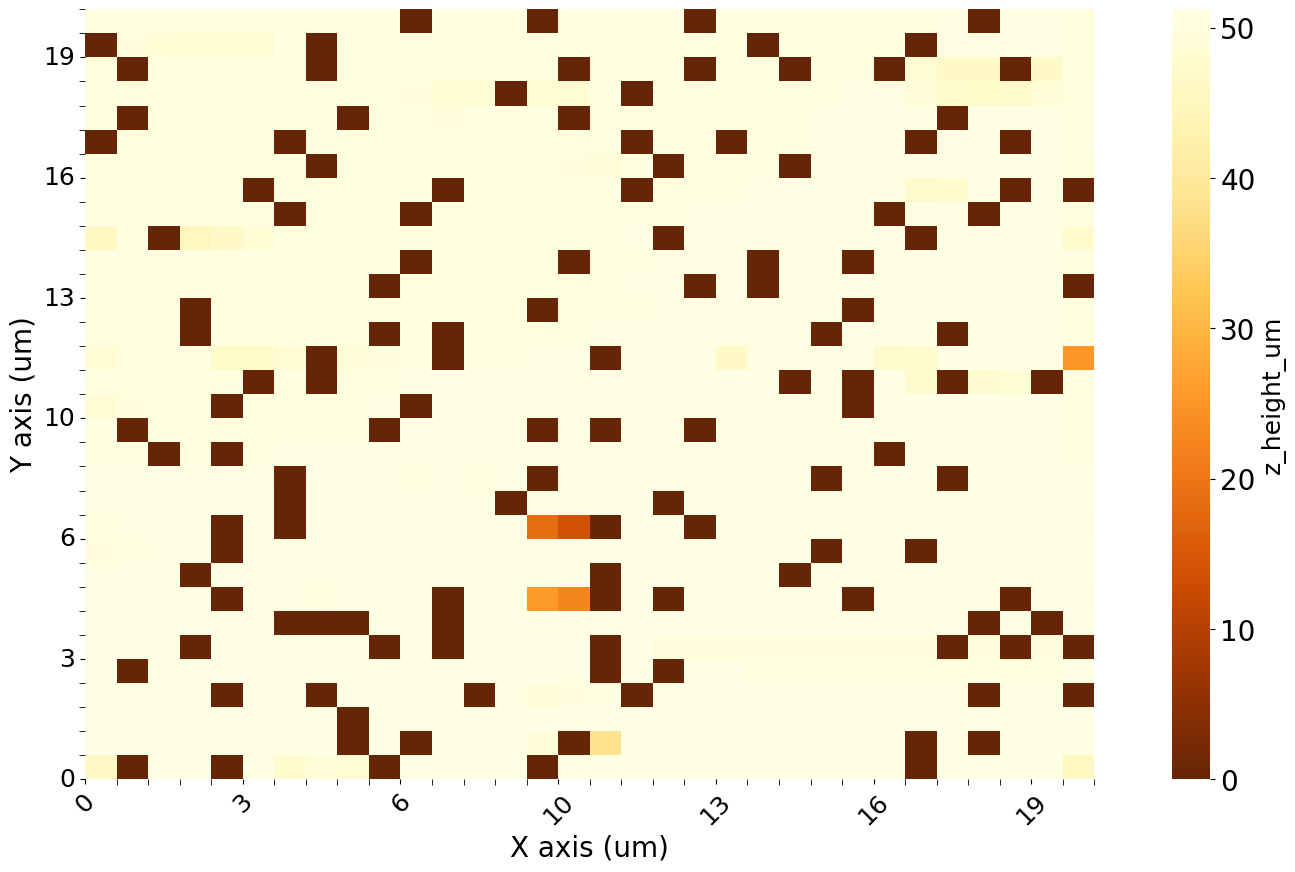

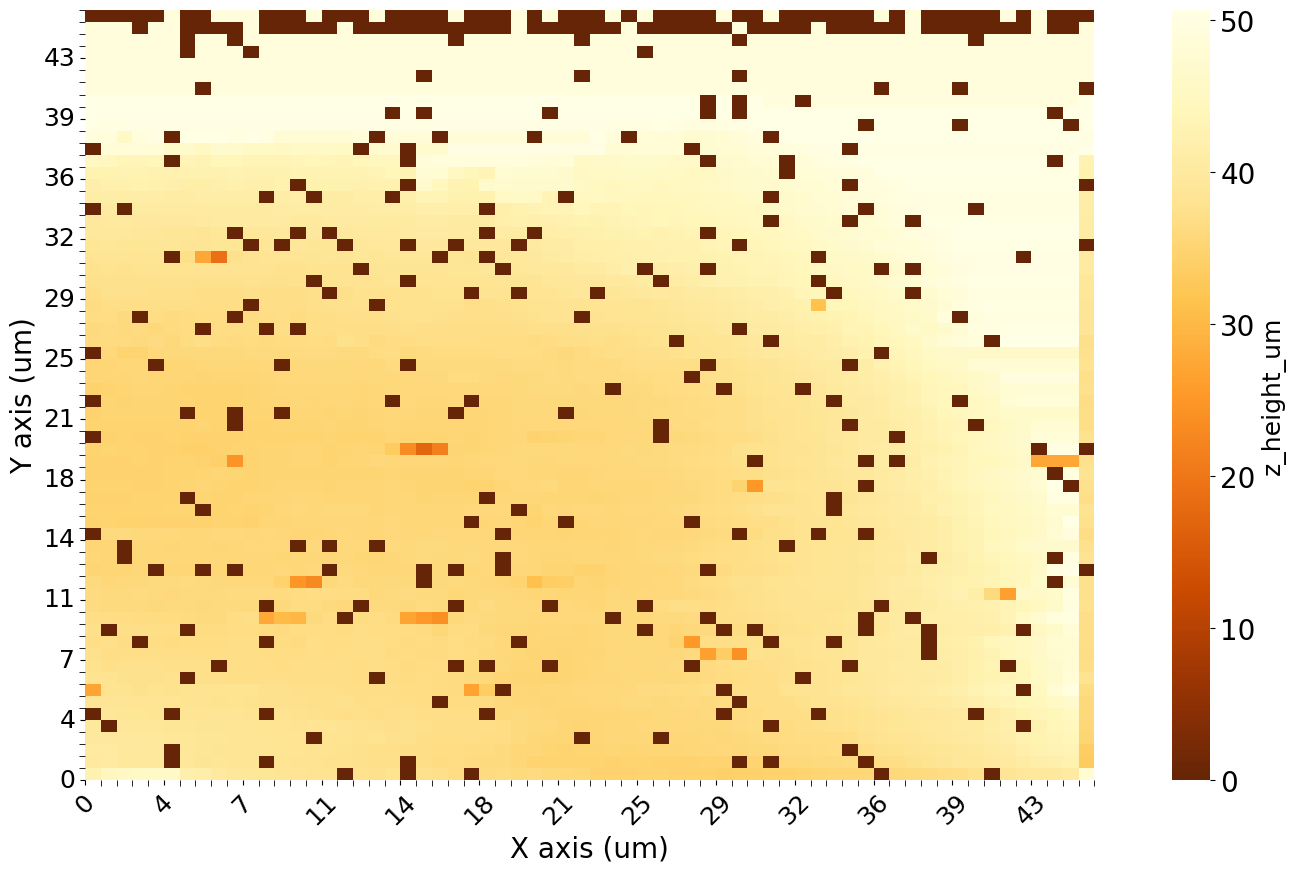

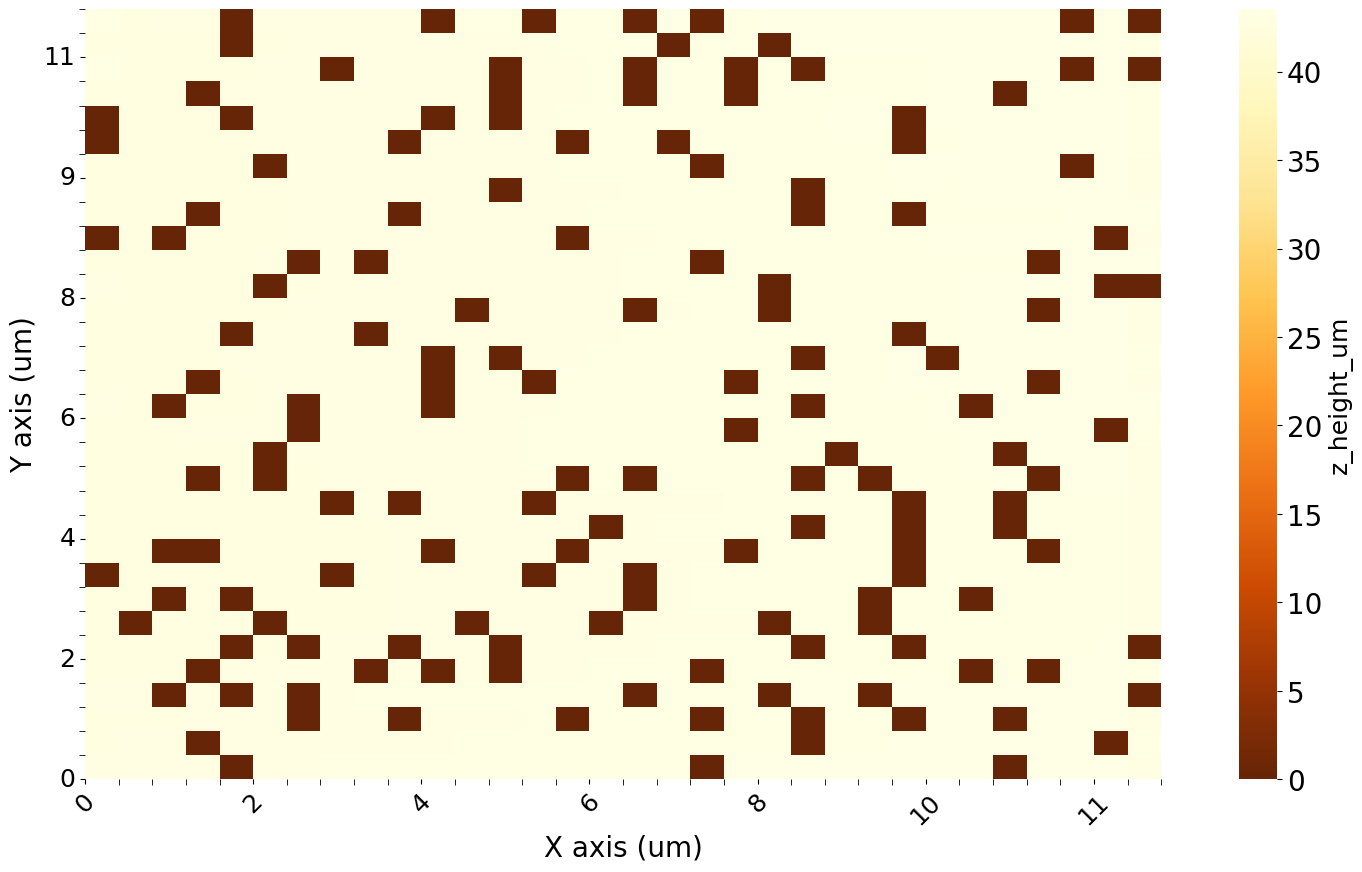

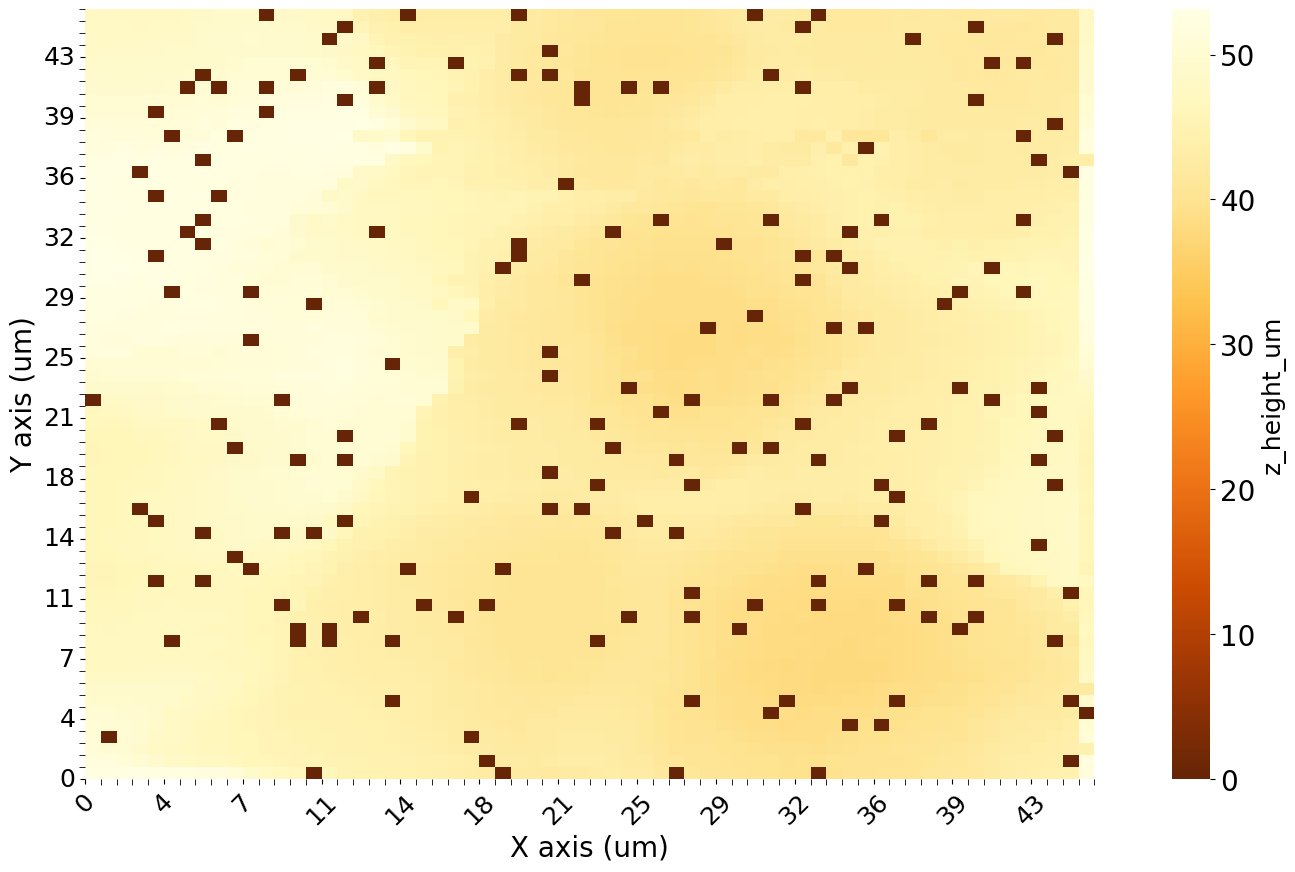

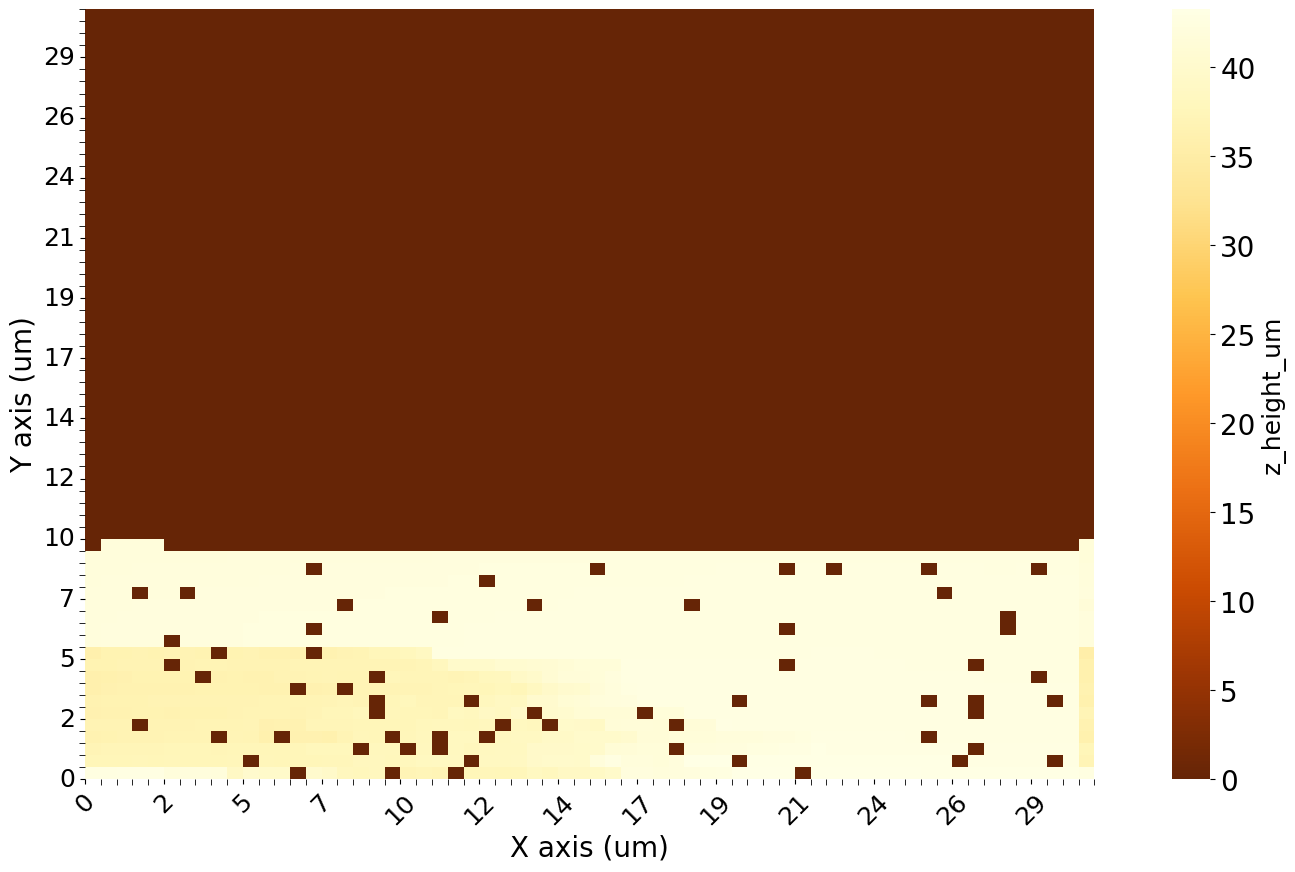

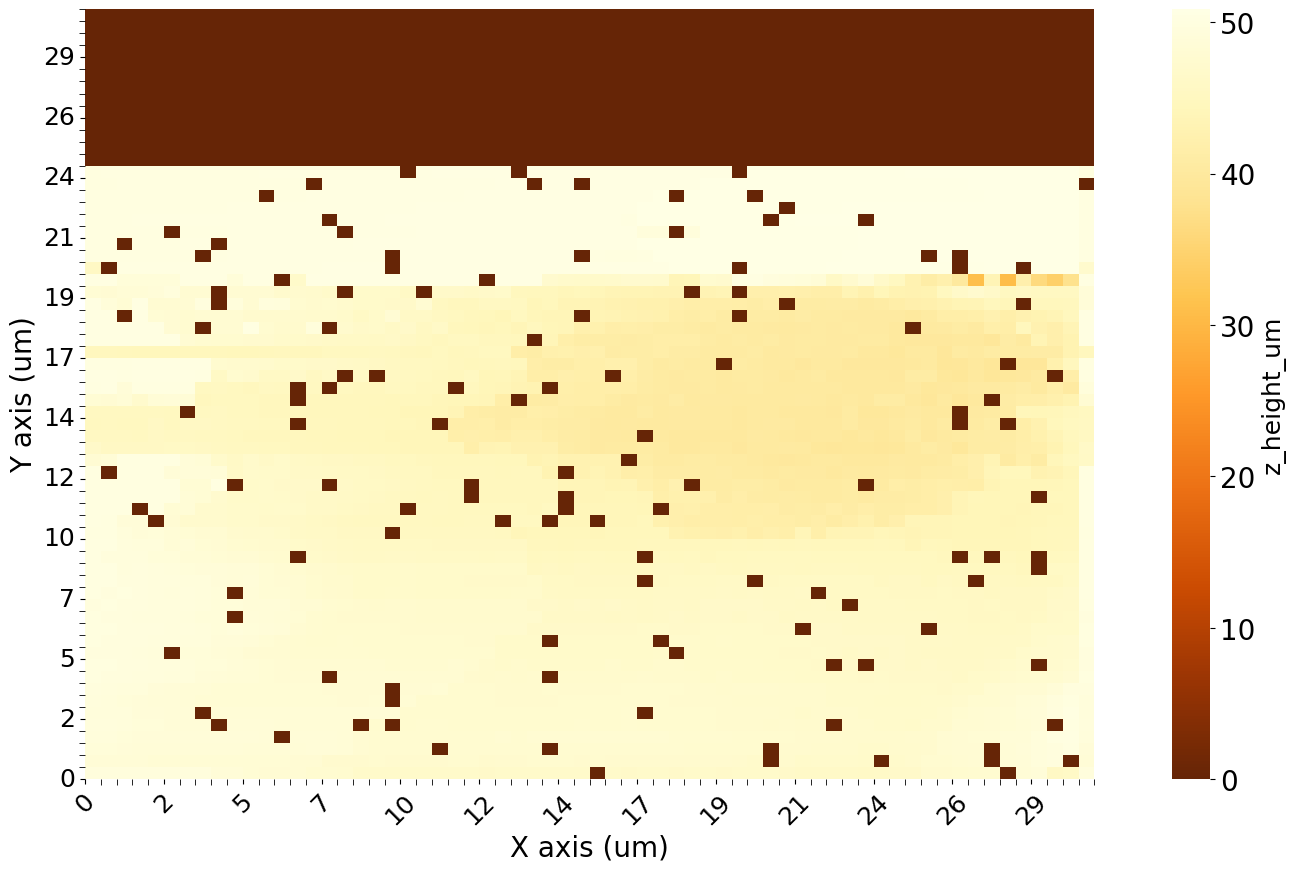

In [ ]:
format = 'png'
for map_path in maps_to_analyze_paths:
    try:
        _ = maps.checkMapFileNULL(map_path, CSVfile=False)
        df_map = maps.load_map_psnex(map_path)
        params,_ = maps.get_map_parameters(map_path)
        map_name = os.path.basename(map_path)
        svg_path = os.path.join(svg_dir, f"{map_name}_nanFalse.{format}")
        _ = maps.create_heatmap(df_map,correct_indices =False, lastColFirst=True,value_key="z_height_um",annot = False, params=params, scale_axis=True, flipAxis=True, save_svg=False,svg_path=svg_path, save_format=format, nan=False, cmap = "YlOrBr",
                                    
                                    
                                    
                                    )
        

        plt.savefig(svg_path, format=format)
        print(f"Saved heatmap for {map_name} to {svg_path}")
    except Exception as e:
        print(f"Error processing map at {map_path}: {e}")

In [6]:
# map_path ='/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_16.42.54.16'

# # _ = maps.checkMapFileNULL(map_path, CSVfile=True)
# df_map = maps.load_map_psnex(map_path)
# params,_ = maps.get_map_parameters(map_path)
# map_name = os.path.basename(map_path)
# print(f"Loaded map: {map_name}")
# svg_path = os.path.join(svg_dir, f"{map_name}.svg")

# _ = maps.create_heatmap(df_map,correct_indices=False, lastColFirst=True,value_key="z_height_um",annot = False, params=params, scale_axis=True, flipAxis=True, save_svg=True,svg_path=svg_path)


# # plt.savefig(svg_path, format='svg')
# # print(f"Saved heatmap for {map_name} to {svg_path}")
